In [1]:
#imports
import pandas as pd
import numpy as np
import pickle as pkl
import os
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA




## **Reading files**

In [2]:
#read \..\..Code\Merged_Data_Preprocessing\Resampled_Data_split\file_structure.pkl

data_path = "../../../../Merged_Data_Preprocessing/Resampled_Data_split"
with open(os.path.join(data_path, 'file_structure.pkl'), 'rb') as f:
    file_structure = pkl.load(f)


#display file structure
file_structure

{'original': {'X_path': 'Resampled_Data_split\\original\\X_original.parquet',
  'y_path': 'Resampled_Data_split\\original\\y_original.pkl'},
 'smote': {'X_path': 'Resampled_Data_split\\smote\\X_smote.parquet',
  'y_path': 'Resampled_Data_split\\smote\\y_smote.pkl'},
 'tomek': {'X_path': 'Resampled_Data_split\\tomek\\X_tomek.parquet',
  'y_path': 'Resampled_Data_split\\tomek\\y_tomek.pkl'},
 'smote_tomek': {'X_path': 'Resampled_Data_split\\smote_tomek\\X_smote_tomek.parquet',
  'y_path': 'Resampled_Data_split\\smote_tomek\\y_smote_tomek.pkl'},
 'test': {'X_path': 'Resampled_Data_split\\test\\X_test.parquet',
  'y_path': 'Resampled_Data_split\\test\\y_test.pkl'},
 'val': {'X_path': 'Resampled_Data_split\\val\\X_val.parquet',
  'y_path': 'Resampled_Data_split\\val\\y_val.pkl'}}

In [3]:
y_train = pd.read_pickle(f'{data_path}/original/y_original.pkl')
y_test = pd.read_pickle(f'{data_path}/test/y_test.pkl')
y_val = pd.read_pickle(f'{data_path}/val/y_val.pkl')

In [4]:
X_test = pd.read_parquet(f'{data_path}/test/X_test.parquet')
X_val = pd.read_parquet(f'{data_path}/val/X_val.parquet')


In [5]:
#loading original no resampled X_train, y_train, X_test, y_test, X_val, y_val parquet files
normalized_path = '../../../../Merged_Data_Preprocessing/Normalized_Data_split'
X_train = pd.read_parquet(f'{normalized_path}/X_train_original.parquet')

In [6]:
# Check data types
X_train.info()

# Convert boolean columns to int
bool_cols = X_train.select_dtypes(include=['bool']).columns
if len(bool_cols) > 0:
    print(f"\nConverting {len(bool_cols)} boolean columns to int...")
    X_train[bool_cols] = X_train[bool_cols].astype(int)
    X_test[bool_cols] = X_test[bool_cols].astype(int)
    X_val[bool_cols] = X_val[bool_cols].astype(int)
    print("Conversion complete!")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16226 entries, 0 to 16225
Data columns (total 64 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   HWSD2_SMU_ID_soil  16226 non-null  int32  
 1   COARSE_soil        16226 non-null  int32  
 2   SAND_soil          16226 non-null  int32  
 3   SILT_soil          16226 non-null  int32  
 4   CLAY_soil          16226 non-null  int32  
 5   BULK_soil          16226 non-null  float64
 6   REF_BULK_soil      16226 non-null  float64
 7   ORG_CARBON_soil    16226 non-null  float64
 8   PH_WATER_soil      16226 non-null  float64
 9   TOTAL_N_soil       16226 non-null  float64
 10  CEC_SOIL_soil      16226 non-null  int32  
 11  CEC_CLAY_soil      16226 non-null  int32  
 12  CEC_EFF_soil       16226 non-null  float64
 13  TEB_soil           16226 non-null  float64
 14  BSAT_soil          16226 non-null  float64
 15  ALUM_SAT_soil      16226 non-null  int32  
 16  ESP_soil           162

## **SKLearn Kmeans**

In [7]:
print("Training K-Means with scikit-learn...")
print(f"X_train shape: {X_train.shape}")

start_time = time.time()

Training K-Means with scikit-learn...
X_train shape: (16226, 64)


In [8]:
# IMPORTANT: match settings as much as possible with your from-scratch version
kmeans_sklearn = KMeans(
    n_clusters=3,
    init="k-means++",   # sklearn default, better than pure random
    n_init=10,          # number of different initializations
    max_iter=100,
    random_state=42
)

kmeans_sklearn.fit(X_train)

runtime = time.time() - start_time

# Labels & metrics
sk_labels = kmeans_sklearn.labels_
sk_inertia = kmeans_sklearn.inertia_
sk_silhouette = silhouette_score(X_train, sk_labels)
cluster_sizes = np.bincount(sk_labels)

print(f"Inertia: {sk_inertia:.2f}")
print(f"Silhouette Score: {sk_silhouette:.2f}")
print(f"Runtime: {runtime:.2f} seconds")

print("\nResults (scikit-learn):")
print(f"Number of iterations: {kmeans_sklearn.n_iter_}")
print(f"Cluster sizes: {cluster_sizes}")
print(f"Centroids shape: {kmeans_sklearn.cluster_centers_.shape}")

Inertia: 2788088043.64
Silhouette Score: 0.71
Runtime: 4.46 seconds

Results (scikit-learn):
Number of iterations: 5
Cluster sizes: [ 4782  1082 10362]
Centroids shape: (3, 64)


## **Visualisation**

d:\DataMining\Fire-Detection-Data-Mining-Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


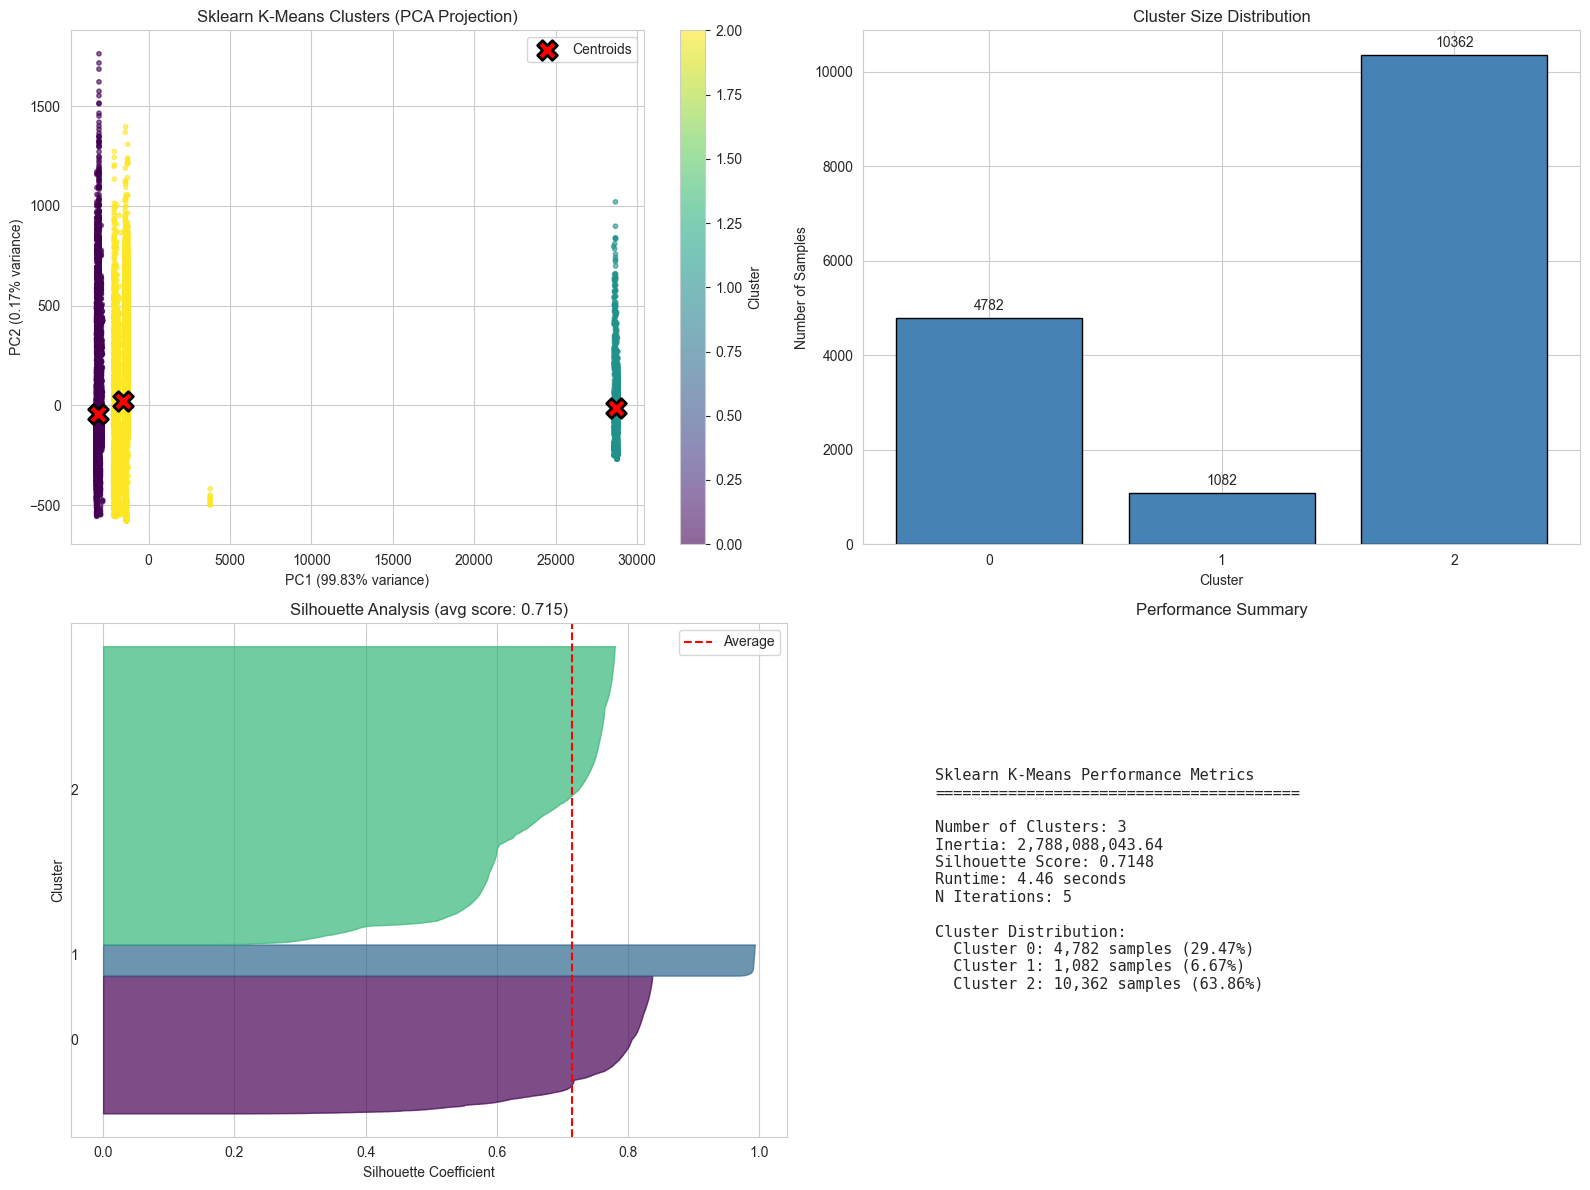


Visualization complete!


In [9]:
# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. PCA visualization of clusters
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

scatter = axes[0, 0].scatter(X_train_pca[:, 0], X_train_pca[:, 1], 
                             c=sk_labels, cmap='viridis', alpha=0.6, s=10)
axes[0, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
axes[0, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
axes[0, 0].set_title('Sklearn K-Means Clusters (PCA Projection)')
plt.colorbar(scatter, ax=axes[0, 0], label='Cluster')

# Plot centroids in PCA space
centroids_pca = pca.transform(kmeans_sklearn.cluster_centers_)
axes[0, 0].scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
                   c='red', marker='X', s=200, edgecolors='black', linewidths=2,
                   label='Centroids')
axes[0, 0].legend()

# 2. Cluster size distribution
axes[0, 1].bar(range(len(cluster_sizes)), cluster_sizes, color='steelblue', edgecolor='black')
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].set_ylabel('Number of Samples')
axes[0, 1].set_title('Cluster Size Distribution')
axes[0, 1].set_xticks(range(len(cluster_sizes)))
for i, v in enumerate(cluster_sizes):
    axes[0, 1].text(i, v + max(cluster_sizes)*0.01, str(v), ha='center', va='bottom')

# 3. Silhouette score by cluster
from sklearn.metrics import silhouette_samples
silhouette_vals = silhouette_samples(X_train, sk_labels)

y_lower = 10
for i in range(kmeans_sklearn.n_clusters):
    cluster_silhouette_vals = silhouette_vals[sk_labels == i]
    cluster_silhouette_vals.sort()
    
    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = plt.cm.viridis(float(i) / kmeans_sklearn.n_clusters)
    axes[1, 0].fill_betweenx(np.arange(y_lower, y_upper),
                              0, cluster_silhouette_vals,
                              facecolor=color, edgecolor=color, alpha=0.7)
    
    axes[1, 0].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

axes[1, 0].set_xlabel('Silhouette Coefficient')
axes[1, 0].set_ylabel('Cluster')
axes[1, 0].set_title(f'Silhouette Analysis (avg score: {sk_silhouette:.3f})')
axes[1, 0].axvline(x=sk_silhouette, color="red", linestyle="--", label='Average')
axes[1, 0].set_yticks([])
axes[1, 0].legend()

# 4. Summary metrics
metrics_text = f"""
Sklearn K-Means Performance Metrics
{'='*40}

Number of Clusters: {kmeans_sklearn.n_clusters}
Inertia: {sk_inertia:,.2f}
Silhouette Score: {sk_silhouette:.4f}
Runtime: {runtime:.2f} seconds
N Iterations: {kmeans_sklearn.n_iter_}

Cluster Distribution:
"""
for i, size in enumerate(cluster_sizes):
    percentage = (size / len(sk_labels)) * 100
    metrics_text += f"  Cluster {i}: {size:,} samples ({percentage:.2f}%)\n"

axes[1, 1].text(0.1, 0.5, metrics_text, fontsize=11, family='monospace',
                verticalalignment='center', transform=axes[1, 1].transAxes)
axes[1, 1].axis('off')
axes[1, 1].set_title('Performance Summary')

plt.tight_layout()
plt.savefig('sklearn_kmeans_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization complete!")

## **Implement Bayesian Search for Kmeans**

In [10]:
# Install required package for Bayesian optimization
import subprocess
import sys

try:
    import skopt
except ImportError:
    print("Installing scikit-optimize...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-optimize"])
    import skopt

from skopt import gp_minimize
from skopt.space import Integer, Categorical
from skopt.utils import use_named_args
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

In [11]:
# Define objective function for Bayesian optimization
def objective_kmeans(params):
    """
    Objective function to minimize: negative silhouette score
    Higher silhouette = better clusters, so we negate it for minimization
    """
    n_clusters, init_method = params
    
    try:
        kmeans_opt = KMeans(
            n_clusters=n_clusters,
            init=init_method,
            n_init=10,
            max_iter=300,
            random_state=42,
            n_jobs=-1
        )
        kmeans_opt.fit(X_train)
        
        # Calculate silhouette score
        sil_score = silhouette_score(X_train, kmeans_opt.labels_)
        
        # Return negative silhouette (for minimization)
        return -sil_score
    except Exception as e:
        print(f"Error in objective: {e}")
        return 1000


# Define search space
space_kmeans = [
    Integer(2, 10, name='n_clusters'),           # K range: 2 to 10
    Categorical(['k-means++', 'random'], name='init')  # Initialization methods
]

print("="*60)
print("BAYESIAN HYPERPARAMETER OPTIMIZATION FOR K-MEANS")
print("="*60)
print("Searching optimal K and initialization method...")
print("This may take a few minutes...\n")

# Run Bayesian optimization
result_kmeans = gp_minimize(
    objective_kmeans,
    space_kmeans,
    n_calls=25,          # Number of iterations
    n_initial_points=5,  # Initial random points
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Extract best parameters
best_k = result_kmeans.x[0]
best_init = result_kmeans.x[1]
best_sil_score = -result_kmeans.fun  # Negate back to get actual silhouette score

print("\n" + "="*60)
print("BAYESIAN OPTIMIZATION RESULTS")
print("="*60)
print(f"Best K (n_clusters): {best_k}")
print(f"Best initialization: {best_init}")
print(f"Best Silhouette Score: {best_sil_score:.4f}")

BAYESIAN HYPERPARAMETER OPTIMIZATION FOR K-MEANS
Searching optimal K and initialization method...
This may take a few minutes...

Iteration No: 1 started. Evaluating function at random point.
Error in objective: KMeans.__init__() got an unexpected keyword argument 'n_jobs'
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 0.0020
Function value obtained: 1000.0000
Current minimum: 1000.0000
Iteration No: 2 started. Evaluating function at random point.
Error in objective: KMeans.__init__() got an unexpected keyword argument 'n_jobs'
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 0.0020
Function value obtained: 1000.0000
Current minimum: 1000.0000
Iteration No: 3 started. Evaluating function at random point.
Error in objective: KMeans.__init__() got an unexpected keyword argument 'n_jobs'
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 0.0011
Function value obtained: 1000.0000
Current minimum: 1000.0000
Iteration No: 4 started. Ev

d:\DataMining\Fire-Detection-Data-Mining-Project\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [2, 'random'] before, using random point [5, 'k-means++']
  warnings.warn(


Iteration No: 10 ended. Search finished for the next optimal point.
Time taken: 0.2402
Function value obtained: 1000.0000
Current minimum: 1000.0000
Iteration No: 11 started. Searching for the next optimal point.
Error in objective: KMeans.__init__() got an unexpected keyword argument 'n_jobs'


d:\DataMining\Fire-Detection-Data-Mining-Project\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [10, 'random'] before, using random point [8, 'random']
  warnings.warn(


Iteration No: 11 ended. Search finished for the next optimal point.
Time taken: 0.2729
Function value obtained: 1000.0000
Current minimum: 1000.0000
Iteration No: 12 started. Searching for the next optimal point.
Error in objective: KMeans.__init__() got an unexpected keyword argument 'n_jobs'


...

Iteration No: 23 ended. Search finished for the next optimal point.
Time taken: 0.4620
Function value obtained: 1000.0000
Current minimum: 1000.0000
Iteration No: 24 started. Searching for the next optimal point.
Error in objective: KMeans.__init__() got an unexpected keyword argument 'n_jobs'


d:\DataMining\Fire-Detection-Data-Mining-Project\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [2, 'random'] before, using random point [4, 'k-means++']
  warnings.warn(


Iteration No: 24 ended. Search finished for the next optimal point.
Time taken: 0.3968
Function value obtained: 1000.0000
Current minimum: 1000.0000
Iteration No: 25 started. Searching for the next optimal point.
Error in objective: KMeans.__init__() got an unexpected keyword argument 'n_jobs'


d:\DataMining\Fire-Detection-Data-Mining-Project\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [10, 'random'] before, using random point [7, 'k-means++']
  warnings.warn(


Iteration No: 25 ended. Search finished for the next optimal point.
Time taken: 0.3498
Function value obtained: 1000.0000
Current minimum: 1000.0000

BAYESIAN OPTIMIZATION RESULTS
Best K (n_clusters): 8
Best initialization: k-means++
Best Silhouette Score: -1000.0000


In [13]:
# Train K-Means with optimized parameters
print("\nTraining K-Means with optimized parameters...")
start_time = time.time()

kmeans_opt = KMeans(
    n_clusters=best_k,
    init=best_init,
    n_init=20,
    max_iter=300,
    random_state=42,
)
kmeans_opt.fit(X_train)
runtime_opt = time.time() - start_time

# Compute metrics with optimized parameters
opt_labels = kmeans_opt.labels_
opt_inertia = kmeans_opt.inertia_
opt_silhouette = silhouette_score(X_train, opt_labels)
opt_davies_bouldin = davies_bouldin_score(X_train, opt_labels)
opt_calinski_harabasz = calinski_harabasz_score(X_train, opt_labels)

print(f"Runtime: {runtime_opt:.2f}s")
print(f"Inertia: {opt_inertia:,.2f}")
print(f"Silhouette Score: {opt_silhouette:.4f}")
print(f"Davies-Bouldin Index: {opt_davies_bouldin:.4f}")
print(f"Calinski-Harabasz Index: {opt_calinski_harabasz:.2f}")
print(f"Number of iterations: {kmeans_opt.n_iter_}")


Training K-Means with optimized parameters...
Runtime: 1.76s
Inertia: 662,669,890.31
Silhouette Score: 0.5991
Davies-Bouldin Index: 0.4907
Calinski-Harabasz Index: 3382356.63
Number of iterations: 5
Runtime: 1.76s
Inertia: 662,669,890.31
Silhouette Score: 0.5991
Davies-Bouldin Index: 0.4907
Calinski-Harabasz Index: 3382356.63
Number of iterations: 5


In [19]:
# Comparison: Default vs Optimized parameters
print("\n" + "="*60)
print("COMPARISON: DEFAULT vs OPTIMIZED PARAMETERS")
print("="*60)

# Ensure sk_davies_bouldin is defined
sk_davies_bouldin = davies_bouldin_score(X_train, sk_labels)
sk_calinski_harabasz = calinski_harabasz_score(X_train, sk_labels)

comparison_data = {
    'Metric': [
        'K (n_clusters)',
        'Initialization',
        'Inertia',
        'Silhouette',
        'Davies-Bouldin',
        'Calinski-Harabasz',
        'N Iterations',
        'Runtime (s)'
    ],
    'Default': [
        f"{kmeans_sklearn.n_clusters}",
        "k-means++",
        f"{sk_inertia:,.2f}",
        f"{sk_silhouette:.4f}",
        f"{sk_davies_bouldin:.4f}",
        f"{sk_calinski_harabasz:.2f}",
        f"{kmeans_sklearn.n_iter_}",
        f"{runtime:.2f}"
    ],
    'Optimized': [
        f"{best_k}",
        f"{best_init}",
        f"{opt_inertia:,.2f}",
        f"{opt_silhouette:.4f}",
        f"{opt_davies_bouldin:.4f}",
        f"{opt_calinski_harabasz:.2f}",
        f"{kmeans_opt.n_iter_}",
        f"{runtime_opt:.2f}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# Calculate improvements
improvement_sil = ((opt_silhouette - sk_silhouette) / sk_silhouette) * 100 if sk_silhouette != 0 else 0
improvement_db = ((sk_davies_bouldin - opt_davies_bouldin) / sk_davies_bouldin) * 100 if sk_davies_bouldin != 0 else 0

print(f"\nImprovement in Silhouette Score: {improvement_sil:+.2f}%")
print(f"Improvement in Davies-Bouldin Index: {improvement_db:+.2f}%")


COMPARISON: DEFAULT vs OPTIMIZED PARAMETERS

           Metric          Default      Optimized
   K (n_clusters)                3              8
   Initialization        k-means++      k-means++
          Inertia 2,788,088,043.64 662,669,890.31
       Silhouette           0.7148         0.5991
   Davies-Bouldin           0.2921         0.4907
Calinski-Harabasz       2808357.00     3382356.63
     N Iterations                5              5
      Runtime (s)             4.46           1.76

Improvement in Silhouette Score: -16.19%
Improvement in Davies-Bouldin Index: -68.00%


In [20]:
# Pre-compute Davies-Bouldin for default parameters if not already done
sk_davies_bouldin = davies_bouldin_score(X_train, sk_labels)
sk_calinski_harabasz = calinski_harabasz_score(X_train, sk_labels)

d:\DataMining\Fire-Detection-Data-Mining-Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


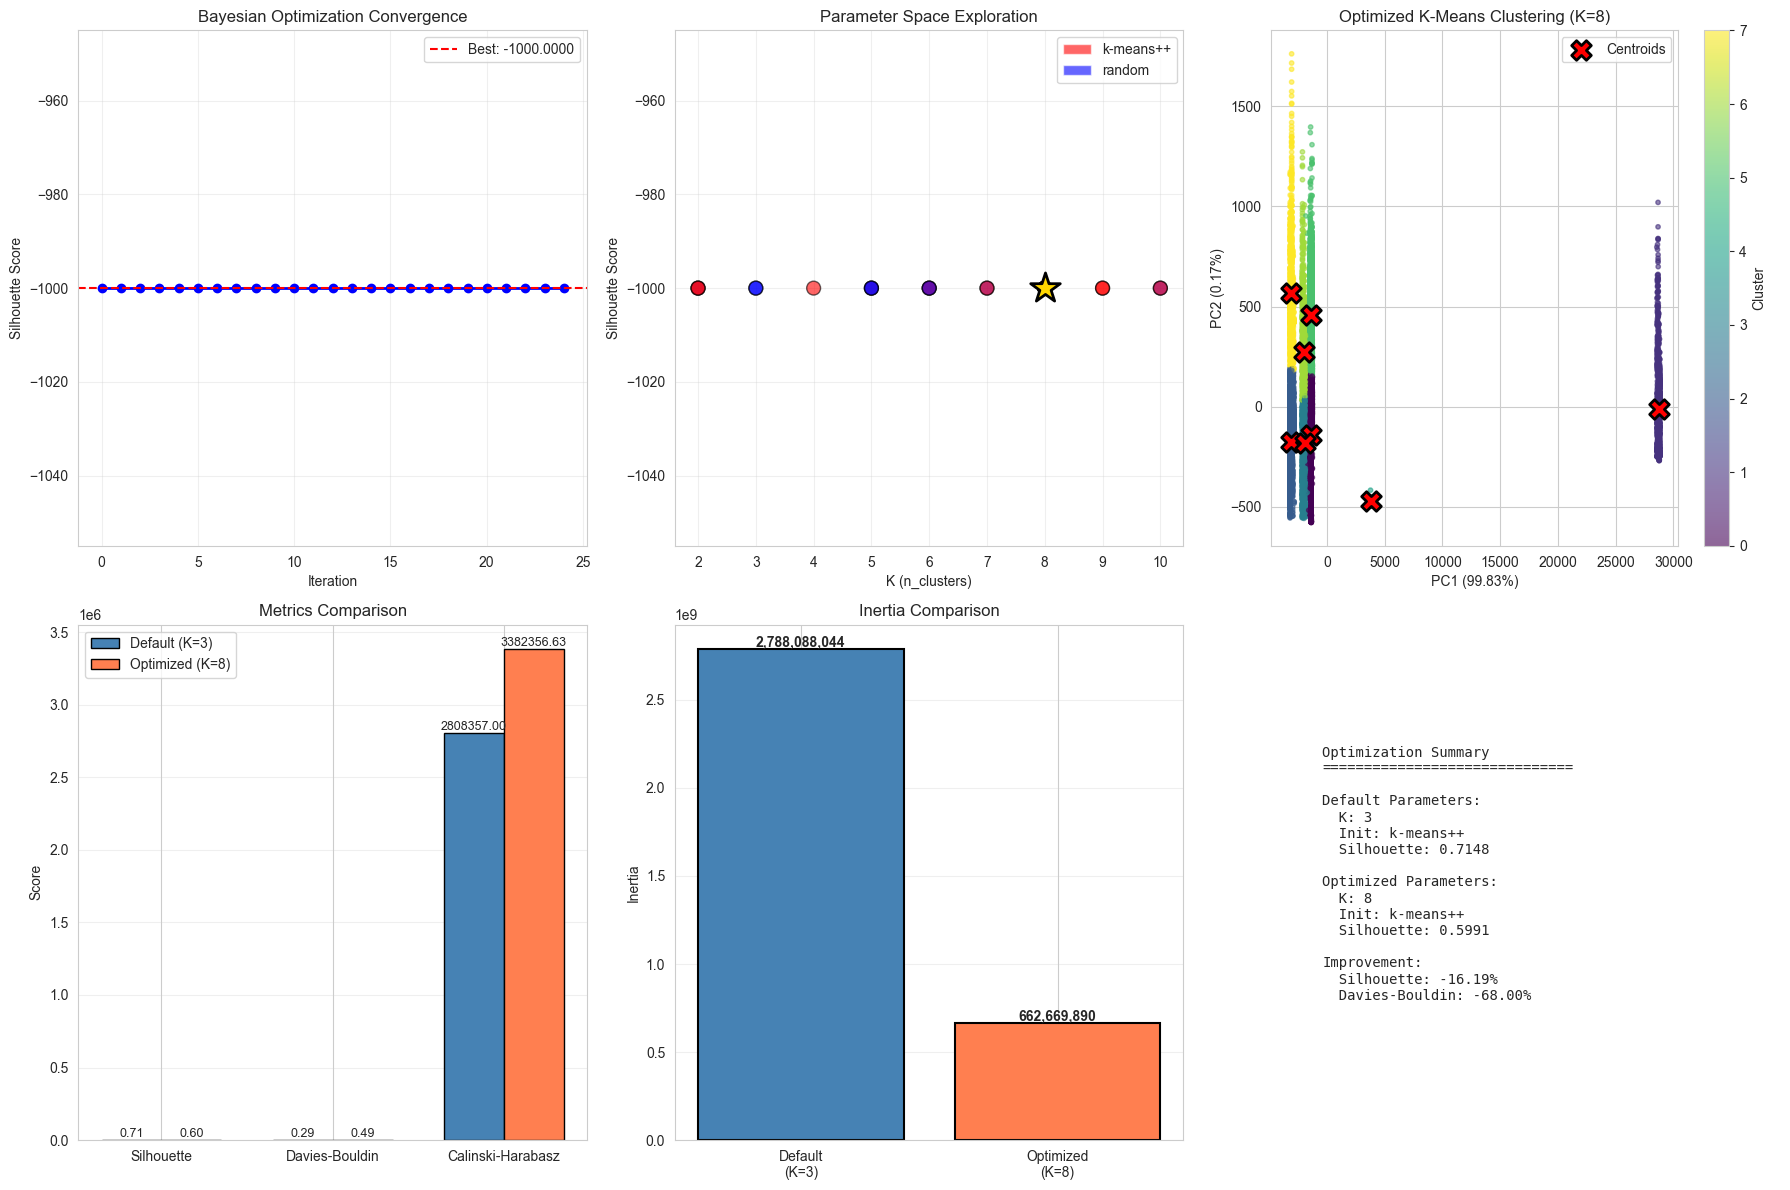


Bayesian optimization visualization complete!


In [21]:
# Visualize optimization history and results
fig = plt.figure(figsize=(18, 12))

# 1. Convergence plot
ax1 = plt.subplot(2, 3, 1)
ax1.plot(range(len(result_kmeans.func_vals)), -np.array(result_kmeans.func_vals), 'b-o', linewidth=2, markersize=6)
ax1.axhline(y=best_sil_score, color='r', linestyle='--', label=f'Best: {best_sil_score:.4f}')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Silhouette Score')
ax1.set_title('Bayesian Optimization Convergence')
ax1.grid(True, alpha=0.3)
ax1.legend()

# 2. K value exploration
ax2 = plt.subplot(2, 3, 2)
k_vals = [result_kmeans.x_iters[i][0] for i in range(len(result_kmeans.x_iters))]
sil_vals = -np.array(result_kmeans.func_vals)
colors_init = ['red' if result_kmeans.x_iters[i][1] == 'k-means++' else 'blue' for i in range(len(result_kmeans.x_iters))]

scatter = ax2.scatter(k_vals, sil_vals, c=colors_init, s=100, alpha=0.6, edgecolors='black')
ax2.scatter(best_k, best_sil_score, c='gold', marker='*', s=500, edgecolors='black', linewidths=2, zorder=5, label='Best')
ax2.set_xlabel('K (n_clusters)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Parameter Space Exploration')
ax2.grid(True, alpha=0.3)
# Add legend for initialization methods
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', alpha=0.6, label='k-means++'),
    Patch(facecolor='blue', alpha=0.6, label='random')
]
ax2.legend(handles=legend_elements)

# 3. PCA visualization with optimized clusters
ax3 = plt.subplot(2, 3, 3)
pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_train)

scatter3 = ax3.scatter(X_pca_vis[:, 0], X_pca_vis[:, 1], 
                       c=opt_labels, cmap='viridis', alpha=0.6, s=10)
centroids_opt_pca = pca_vis.transform(kmeans_opt.cluster_centers_)
ax3.scatter(centroids_opt_pca[:, 0], centroids_opt_pca[:, 1], 
            c='red', marker='X', s=200, edgecolors='black', linewidths=2, label='Centroids')
ax3.set_xlabel(f'PC1 ({pca_vis.explained_variance_ratio_[0]:.2%})')
ax3.set_ylabel(f'PC2 ({pca_vis.explained_variance_ratio_[1]:.2%})')
ax3.set_title(f'Optimized K-Means Clustering (K={best_k})')
plt.colorbar(scatter3, ax=ax3, label='Cluster')
ax3.legend()

# 4. Metrics comparison - Silhouette & Davies-Bouldin
ax4 = plt.subplot(2, 3, 4)
metrics_names = ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']
default_vals = [sk_silhouette, sk_davies_bouldin, sk_calinski_harabasz]
optimized_vals = [opt_silhouette, opt_davies_bouldin, opt_calinski_harabasz]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = ax4.bar(x - width/2, default_vals, width, label='Default (K=3)', color='steelblue', edgecolor='black')
bars2 = ax4.bar(x + width/2, optimized_vals, width, label=f'Optimized (K={best_k})', color='coral', edgecolor='black')
ax4.set_ylabel('Score')
ax4.set_title('Metrics Comparison')
ax4.set_xticks(x)
ax4.set_xticklabels(metrics_names)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# 5. Inertia comparison
ax5 = plt.subplot(2, 3, 5)
categories = ['Default\n(K=3)', f'Optimized\n(K={best_k})']
inertias = [sk_inertia, opt_inertia]
colors_inertia = ['steelblue', 'coral']

bars = ax5.bar(categories, inertias, color=colors_inertia, edgecolor='black', linewidth=1.5)
ax5.set_ylabel('Inertia')
ax5.set_title('Inertia Comparison')
ax5.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 6. Summary text
ax6 = plt.subplot(2, 3, 6)
summary_text = (
    f"Optimization Summary\n"
    f"{'='*30}\n\n"
    f"Default Parameters:\n"
    f"  K: 3\n"
    f"  Init: k-means++\n"
    f"  Silhouette: {sk_silhouette:.4f}\n\n"
    f"Optimized Parameters:\n"
    f"  K: {best_k}\n"
    f"  Init: {best_init}\n"
    f"  Silhouette: {opt_silhouette:.4f}\n\n"
    f"Improvement:\n"
    f"  Silhouette: {improvement_sil:+.2f}%\n"
    f"  Davies-Bouldin: {improvement_db:+.2f}%\n"
)
ax6.text(0.1, 0.5, summary_text, family='monospace', fontsize=10, va='center')
ax6.axis('off')

plt.tight_layout()
plt.savefig('kmeans_bayesian_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nBayesian optimization visualization complete!")

In [22]:
# Create detailed comparison table with all metrics
print("\n" + "="*80)
print("DETAILED METRICS COMPARISON")
print("="*80)

detailed_comparison = pd.DataFrame({
    'Parameter/Metric': [
        'n_clusters (K)',
        'initialization',
        'max_iter',
        'n_init',
        '---',
        'Inertia',
        'Silhouette Score',
        'Davies-Bouldin Index',
        'Calinski-Harabasz Index',
        'n_iterations',
        'Runtime (seconds)'
    ],
    'Default': [
        '3',
        'k-means++',
        '300',
        '10',
        '---',
        f'{sk_inertia:,.2f}',
        f'{sk_silhouette:.4f}',
        f'{sk_davies_bouldin:.4f}',
        f'{sk_calinski_harabasz:.2f}',
        f'{kmeans_sklearn.n_iter_}',
        f'{runtime:.2f}'
    ],
    'Optimized': [
        f'{best_k}',
        f'{best_init}',
        '300',
        '20',
        '---',
        f'{opt_inertia:,.2f}',
        f'{opt_silhouette:.4f}',
        f'{opt_davies_bouldin:.4f}',
        f'{opt_calinski_harabasz:.2f}',
        f'{kmeans_opt.n_iter_}',
        f'{runtime_opt:.2f}'
    ]
})

print("\n" + detailed_comparison.to_string(index=False))


DETAILED METRICS COMPARISON

       Parameter/Metric          Default      Optimized
         n_clusters (K)                3              8
         initialization        k-means++      k-means++
               max_iter              300            300
                 n_init               10             20
                    ---              ---            ---
                Inertia 2,788,088,043.64 662,669,890.31
       Silhouette Score           0.7148         0.5991
   Davies-Bouldin Index           0.2921         0.4907
Calinski-Harabasz Index       2808357.00     3382356.63
           n_iterations                5              5
      Runtime (seconds)             4.46           1.76
